Mounted at /content/drive
Train sequence shape: (333929, 6, 24) (333929,)
Val sequence shape  : (47264, 6, 24) (47264,)
Test sequence shape : (94644, 6, 24) (94644,)
Epoch 1/30
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - accuracy: 0.7164 - loss: 1.0873 - val_accuracy: 0.7642 - val_loss: 0.4905
Epoch 2/30
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.7443 - loss: 0.9683 - val_accuracy: 0.7726 - val_loss: 0.4511
Epoch 3/30
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.7549 - loss: 0.8714 - val_accuracy: 0.7737 - val_loss: 0.4384
Epoch 4/30
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.7653 - loss: 0.7870 - val_accuracy: 0.7928 - val_loss: 0.4079
Epoch 5/30
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.7820 - loss: 0.7030 - val_accuracy: 0.7847 - val_loss: 0.4107
Epoch 6/30
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.8027 - loss: 0.6386 - val_accuracy: 0.7888 - val_loss: 0.4189
Epoch 7/30
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 18s 7m

,Model,Accuracy,Precision,Recall,F1-score,AUROC,AUPRC
0,XGBoost + GRU,0.8904,0.003576,0.373737,0.007083,0.7899,0.004155


Classification Report:


,precision,recall,f1-score,support
0,0.999264,0.890941,0.941999,94545.0000
1,0.003576,0.373737,0.007083,99.0000
accuracy,0.890400,0.890400,0.890400,0.8904
macro avg,0.501420,0.632339,0.474541,94644.0000
weighted avg,0.998223,0.890400,0.941021,94644.0000


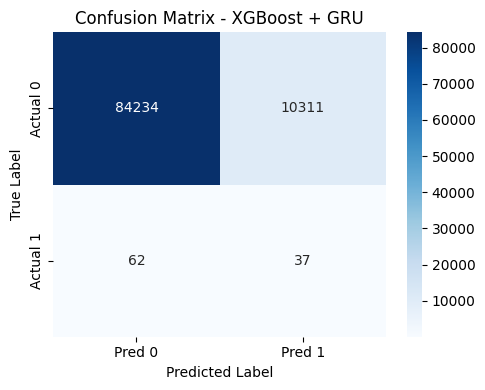

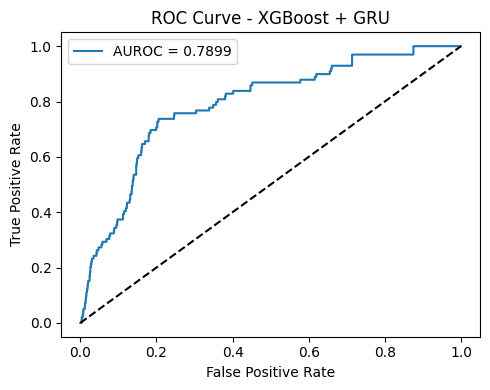

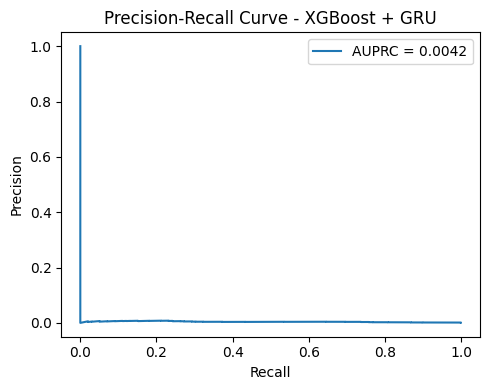

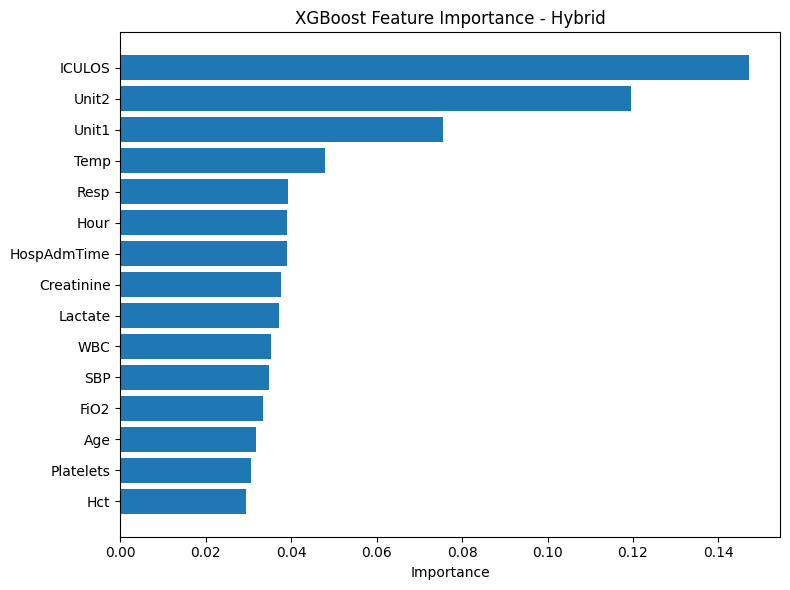

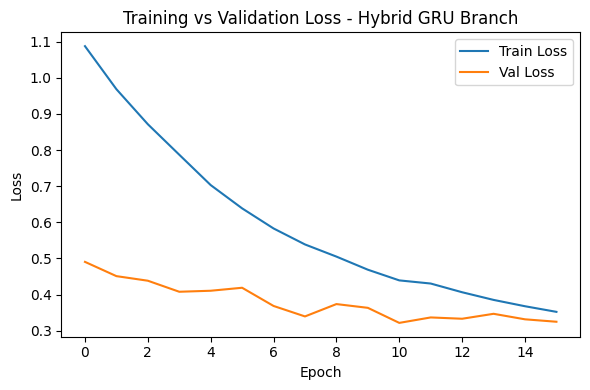

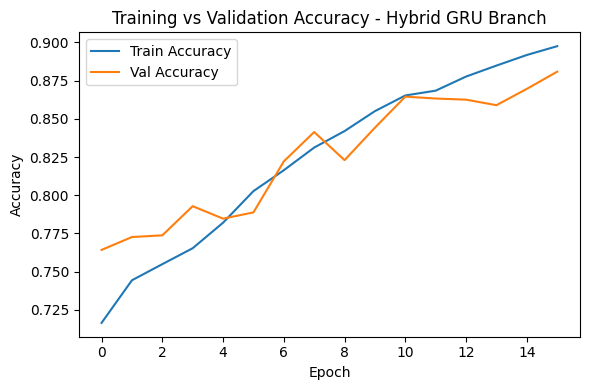


All outputs saved successfully in:
/content/drive/MyDrive/datamining/results/model_7_xgboost_gru_hybrid

Status marked as DONE.


In [1]:
# ==========================================
# MODEL 7: XGBOOST + GRU HYBRID (CORRECTED)
# SAVE EVERYTHING TO DRIVE + RESUME SUPPORT
# ==========================================

# 1) Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# 2) Install if needed
# !pip install xgboost tensorflow -q

# 3) Imports
import os
import json
import joblib
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)

from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 4) Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# 5) Paths
base_dir = "/content/drive/MyDrive/datamining"
data_path = os.path.join(base_dir, "Dataset.csv")
save_dir = os.path.join(base_dir, "results", "model_7_xgboost_gru_hybrid")
os.makedirs(save_dir, exist_ok=True)

status_file = os.path.join(save_dir, "status.txt")

# 6) Skip if already done
if os.path.exists(status_file):
    with open(status_file, "r") as f:
        status = f.read().strip()
    if status == "DONE":
        print("Model 7 already completed. Files are saved in Drive:")
        print(save_dir)
        raise SystemExit

# 7) Load dataset
df = pd.read_csv(data_path)

# 8) Basic cleaning
drop_cols = ["Unnamed: 0", "EtCO2"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

df = df.dropna(subset=["SepsisLabel", "Patient_ID"])
df = df.sort_values(["Patient_ID", "Hour"]).reset_index(drop=True)

# Make types consistent
df["Patient_ID"] = df["Patient_ID"].astype(int)
df["Hour"] = df["Hour"].astype(int)
df["SepsisLabel"] = df["SepsisLabel"].astype(int)

# 9) Drop very high missing columns (>90%), but keep some important clinical columns
missing_percent = df.isnull().mean() * 100
important_keep = ["Lactate", "Platelets", "Creatinine", "WBC"]
high_missing_cols = missing_percent[missing_percent > 90].index.tolist()
high_missing_cols = [
    c for c in high_missing_cols
    if c not in important_keep and c not in ["SepsisLabel", "Patient_ID", "Hour"]
]
df = df.drop(columns=high_missing_cols)

pd.DataFrame({"dropped_columns": high_missing_cols}).to_csv(
    os.path.join(save_dir, "dropped_columns.csv"), index=False
)

# 10) Patient-wise forward fill
exclude_ffill = ["SepsisLabel", "Patient_ID", "Hour"]
ffill_cols = [c for c in df.columns if c not in exclude_ffill]
df[ffill_cols] = df.groupby("Patient_ID")[ffill_cols].ffill()

# 11) Feature / target
target_col = "SepsisLabel"
group_col = "Patient_ID"
time_col = "Hour"
feature_cols = [c for c in df.columns if c not in [target_col, group_col]]

# 12) Patient-wise split: train / val / test
patient_df = df[[group_col, target_col]].groupby(group_col)[target_col].max().reset_index()

train_patients, test_patients = train_test_split(
    patient_df,
    test_size=0.2,
    random_state=42,
    stratify=patient_df[target_col]
)

train_patients, val_patients = train_test_split(
    train_patients,
    test_size=0.125,   # ~70/10/20
    random_state=42,
    stratify=train_patients[target_col]
)

train_ids = set(train_patients[group_col])
val_ids   = set(val_patients[group_col])
test_ids  = set(test_patients[group_col])

train_df = df[df[group_col].isin(train_ids)].copy()
val_df   = df[df[group_col].isin(val_ids)].copy()
test_df  = df[df[group_col].isin(test_ids)].copy()

# 13) Save split info
split_info = {
    "train_rows": int(len(train_df)),
    "val_rows": int(len(val_df)),
    "test_rows": int(len(test_df)),
    "train_patients": int(len(train_ids)),
    "val_patients": int(len(val_ids)),
    "test_patients": int(len(test_ids)),
    "n_features": int(len(feature_cols))
}
with open(os.path.join(save_dir, "split_info.json"), "w") as f:
    json.dump(split_info, f, indent=2)

# 14) Imputation
imputer = SimpleImputer(strategy="median")

X_train_tab = pd.DataFrame(imputer.fit_transform(train_df[feature_cols]), columns=feature_cols, index=train_df.index)
X_val_tab   = pd.DataFrame(imputer.transform(val_df[feature_cols]), columns=feature_cols, index=val_df.index)
X_test_tab  = pd.DataFrame(imputer.transform(test_df[feature_cols]), columns=feature_cols, index=test_df.index)

joblib.dump(imputer, os.path.join(save_dir, "imputer.pkl"))

# 15) Scaling for GRU branch
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_tab), columns=feature_cols, index=train_df.index)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val_tab), columns=feature_cols, index=val_df.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test_tab), columns=feature_cols, index=test_df.index)

joblib.dump(scaler, os.path.join(save_dir, "scaler.pkl"))

# 16) Build sequence dataframes for GRU
train_df_seq = train_df[[group_col, time_col, target_col]].copy()
val_df_seq   = val_df[[group_col, time_col, target_col]].copy()
test_df_seq  = test_df[[group_col, time_col, target_col]].copy()

for col in feature_cols:
    train_df_seq[col] = X_train_scaled[col].values
    val_df_seq[col]   = X_val_scaled[col].values
    test_df_seq[col]  = X_test_scaled[col].values

# 17) Sequence maker
WINDOW = 6

def make_sequences(dataframe, feature_cols, target_col="SepsisLabel", patient_col="Patient_ID", time_col="Hour", window=6):
    X_seq, y_seq, meta = [], [], []

    dataframe = dataframe.sort_values([patient_col, time_col]).reset_index(drop=True)

    for pid, group in dataframe.groupby(patient_col):
        group = group.sort_values(time_col).reset_index(drop=True)

        if len(group) < window:
            continue

        features = group[feature_cols].values
        labels = group[target_col].astype(int).values
        hours = group[time_col].values

        for i in range(window - 1, len(group)):
            seq_x = features[i - window + 1:i + 1]
            seq_y = labels[i]

            X_seq.append(seq_x)
            y_seq.append(seq_y)
            meta.append({
                "Patient_ID": int(pid),
                "Hour": int(hours[i])
            })

    X_seq = np.array(X_seq, dtype=np.float32)
    y_seq = np.array(y_seq, dtype=np.int32)
    meta_df = pd.DataFrame(meta)

    return X_seq, y_seq, meta_df

X_train_seq, y_train_seq, train_meta = make_sequences(train_df_seq, feature_cols, window=WINDOW)
X_val_seq, y_val_seq, val_meta       = make_sequences(val_df_seq, feature_cols, window=WINDOW)
X_test_seq, y_test_seq, test_meta    = make_sequences(test_df_seq, feature_cols, window=WINDOW)

print("Train sequence shape:", X_train_seq.shape, y_train_seq.shape)
print("Val sequence shape  :", X_val_seq.shape, y_val_seq.shape)
print("Test sequence shape :", X_test_seq.shape, y_test_seq.shape)

seq_info = {
    "window_size": WINDOW,
    "train_sequences": int(len(X_train_seq)),
    "val_sequences": int(len(X_val_seq)),
    "test_sequences": int(len(X_test_seq))
}
with open(os.path.join(save_dir, "sequence_info.json"), "w") as f:
    json.dump(seq_info, f, indent=2)

# 18) Train XGBoost on tabular branch
y_train_tab = train_df[target_col].astype(int)
y_test_tab  = test_df[target_col].astype(int)

neg = (y_train_tab == 0).sum()
pos = (y_train_tab == 1).sum()
scale_pos_weight = neg / pos if pos > 0 else 1.0

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_tab, y_train_tab)
joblib.dump(xgb_model, os.path.join(save_dir, "xgboost_model.pkl"))

# 19) Train GRU branch
neg_seq = int((y_train_seq == 0).sum())
pos_seq = int((y_train_seq == 1).sum())

if pos_seq > 0:
    class_weight = {0: 1.0, 1: neg_seq / pos_seq}
else:
    class_weight = {0: 1.0, 1: 1.0}

gru_model = Sequential([
    GRU(64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]), return_sequences=False),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

gru_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

best_model_path = os.path.join(save_dir, "best_gru_model.keras")

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath=best_model_path,
        monitor="val_loss",
        save_best_only=True
    )
]

history = gru_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=30,
    batch_size=128,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

gru_model.save(os.path.join(save_dir, "gru_model.keras"))
history_df = pd.DataFrame(history.history)
history_df.to_csv(os.path.join(save_dir, "training_history.csv"), index=False)

# 20) GRU predictions on sequence test set
gru_prob = gru_model.predict(X_test_seq, batch_size=256).ravel()

# 21) Correct alignment: Patient_ID + Hour based merge
test_meta_align = test_meta.copy()
test_meta_align["Patient_ID"] = test_meta_align["Patient_ID"].astype(int)
test_meta_align["Hour"] = test_meta_align["Hour"].astype(int)

test_df_align = test_df.copy()
test_df_align["Patient_ID"] = test_df_align["Patient_ID"].astype(int)
test_df_align["Hour"] = test_df_align["Hour"].astype(int)

# preserve original row index
test_df_align = test_df_align.reset_index().rename(columns={"index": "orig_index"})

aligned_df = test_meta_align.merge(
    test_df_align[["orig_index", "Patient_ID", "Hour", target_col]],
    on=["Patient_ID", "Hour"],
    how="inner"
)

print("Aligned XGBoost test rows:", aligned_df.shape[0])
print("GRU test rows            :", len(gru_prob))

if aligned_df.shape[0] == 0:
    raise ValueError("Alignment failed: no matching rows found between GRU sequence endpoints and XGBoost tabular rows.")

aligned_indices = aligned_df["orig_index"].values

X_test_aligned_tab = X_test_tab.loc[aligned_indices].copy()
y_test_aligned = test_df.loc[aligned_indices, target_col].astype(int).values

# safety trim
min_len = min(len(X_test_aligned_tab), len(gru_prob), len(y_test_aligned), len(aligned_df))
X_test_aligned_tab = X_test_aligned_tab.iloc[:min_len].copy()
y_test_aligned = y_test_aligned[:min_len]
gru_prob = gru_prob[:min_len]
aligned_df = aligned_df.iloc[:min_len].copy()

xgb_prob_aligned = xgb_model.predict_proba(X_test_aligned_tab)[:, 1]

# 22) Hybrid fusion (simple probability average)
hybrid_prob = (xgb_prob_aligned + gru_prob) / 2.0
hybrid_pred = (hybrid_prob >= 0.5).astype(int)

# 23) Metrics
acc   = accuracy_score(y_test_aligned, hybrid_pred)
prec  = precision_score(y_test_aligned, hybrid_pred, zero_division=0)
rec   = recall_score(y_test_aligned, hybrid_pred, zero_division=0)
f1    = f1_score(y_test_aligned, hybrid_pred, zero_division=0)
auroc = roc_auc_score(y_test_aligned, hybrid_prob)
auprc = average_precision_score(y_test_aligned, hybrid_prob)

metrics_df = pd.DataFrame([{
    "Model": "XGBoost + GRU",
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1-score": f1,
    "AUROC": auroc,
    "AUPRC": auprc
}])

print("\nFinal Metrics:")
display(metrics_df)
metrics_df.to_csv(os.path.join(save_dir, "metrics.csv"), index=False)

# 24) Classification report
report_dict = classification_report(y_test_aligned, hybrid_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).transpose()
print("Classification Report:")
display(report_df)
report_df.to_csv(os.path.join(save_dir, "classification_report.csv"))

# 25) Save predictions
pred_df = aligned_df[["Patient_ID", "Hour"]].copy()
pred_df["y_true"] = y_test_aligned
pred_df["xgb_prob"] = xgb_prob_aligned
pred_df["gru_prob"] = gru_prob
pred_df["hybrid_prob"] = hybrid_prob
pred_df["y_pred"] = hybrid_pred
pred_df.to_csv(os.path.join(save_dir, "predictions.csv"), index=False)

# 26) Confusion Matrix
cm = confusion_matrix(y_test_aligned, hybrid_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["Actual 0", "Actual 1"])
plt.title("Confusion Matrix - XGBoost + GRU")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# 27) ROC Curve
fpr, tpr, _ = roc_curve(y_test_aligned, hybrid_prob)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUROC = {auroc:.4f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost + GRU")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "roc_curve.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# 28) PR Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test_aligned, hybrid_prob)

plt.figure(figsize=(5,4))
plt.plot(recall_vals, precision_vals, label=f"AUPRC = {auprc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - XGBoost + GRU")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "pr_curve.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# 29) XGBoost feature importance
fi_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

fi_df.to_csv(os.path.join(save_dir, "xgb_feature_importance.csv"), index=False)

plt.figure(figsize=(8,6))
top_fi = fi_df.head(15).sort_values("Importance", ascending=True)
plt.barh(top_fi["Feature"], top_fi["Importance"])
plt.title("XGBoost Feature Importance - Hybrid")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "feature_importance.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# 30) GRU training curves
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Training vs Validation Loss - Hybrid GRU Branch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "loss_curve.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

plt.figure(figsize=(6,4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Training vs Validation Accuracy - Hybrid GRU Branch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "accuracy_curve.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# 31) Save extra info
fusion_info = {
    "fusion_type": "simple_probability_average",
    "window_size": WINDOW,
    "alignment_type": "Patient_ID_Hour_merge"
}
with open(os.path.join(save_dir, "fusion_info.json"), "w") as f:
    json.dump(fusion_info, f, indent=2)

# 32) Mark as done
with open(status_file, "w") as f:
    f.write("DONE")

print("\nAll outputs saved successfully in:")
print(save_dir)
print("\nStatus marked as DONE.")